In [1]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
# N2 — scan active space size, holding the molecule fixed
symbols = ['N', 'N']
geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 2.1]])
mol = qml.qchem.Molecule(symbols, geometry, basis_name='sto-3g')
core, one, two = qml.qchem.electron_integrals(mol)()

n_orbs = one.shape[0]
print("Total spatial orbitals available:", n_orbs)

active_sizes, qubit_counts, gate_counts = [], [], []
for n_act in range(2, n_orbs + 1):
    o = one[:n_act, :n_act]
    t = two[:n_act, :n_act, :n_act, :n_act]
    est = qml.estimator.DoubleFactorization(o, t)
    active_sizes.append(n_act); qubit_counts.append(est.qubits); gate_counts.append(est.gates)
    print(f"active orbitals={n_act}: qubits={est.qubits}, Toffoli={est.gates:.3e}")

Total spatial orbitals available: 10
active orbitals=2: qubits=123, Toffoli=2.708e+07
active orbitals=3: qubits=131, Toffoli=4.699e+07
active orbitals=4: qubits=139, Toffoli=7.220e+07
active orbitals=5: qubits=244, Toffoli=9.590e+07
active orbitals=6: qubits=269, Toffoli=1.194e+08
active orbitals=7: qubits=291, Toffoli=1.473e+08
active orbitals=8: qubits=314, Toffoli=1.854e+08
active orbitals=9: qubits=341, Toffoli=2.258e+08
active orbitals=10: qubits=364, Toffoli=2.697e+08


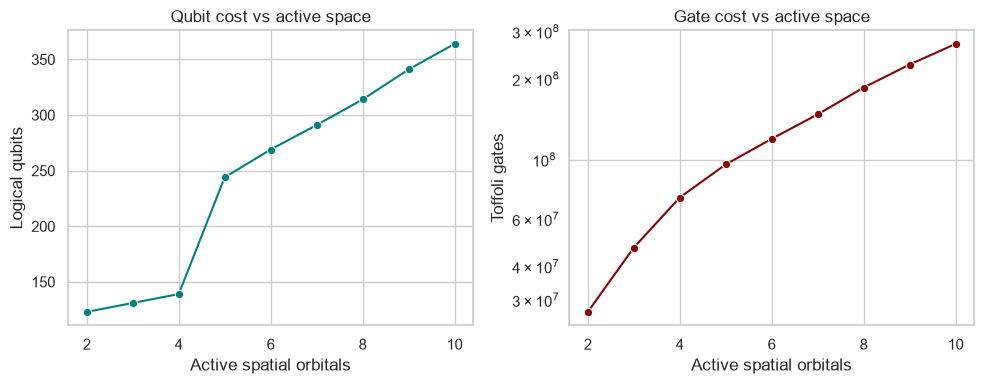

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(x=active_sizes, y=qubit_counts, marker="o", ax=ax1, color="teal")
ax1.set_xlabel("Active spatial orbitals"); ax1.set_ylabel("Logical qubits"); ax1.set_title("Qubit cost vs active space")
sns.lineplot(x=active_sizes, y=gate_counts, marker="o", ax=ax2, color="darkred")
ax2.set_xlabel("Active spatial orbitals"); ax2.set_ylabel("Toffoli gates"); ax2.set_yscale("log"); ax2.set_title("Gate cost vs active space")
plt.tight_layout(); plt.savefig("active_space_scaling.png", dpi=120, bbox_inches="tight"); plt.show()